# Coffee Quality & Pricing Intelligence

## Project Objective

This project analyzes coffee quality and pricing data to identify the factors associated with coffee quality scores and market prices.

### Key Business Questions

1. Which coffee characteristics are associated with higher quality scores?
2. How do origin, processing method, certification, and buyer segment relate to coffee quality and price?
3. Which factors are most strongly associated with coffee quality when controlling for other variables?
4. Are there potential opportunities where high-quality coffee receives relatively lower prices?

### Analytical Approach

- Data cleaning and validation
- Exploratory data analysis
- Descriptive statistics
- Correlation analysis
- Regression modeling
- Business-oriented interpretation

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load and Validate the Source Data

The coffee dataset contains the main analytical variables, while the metadata file provides record-type information used to identify duplicate and revised records.

Before analysis, the two datasets are validated using record IDs to ensure that they can be correctly linked.

In [3]:
metadata = pd.read_csv("../data/coffee_record_metadata.csv")
coffee = pd.read_csv("../data/coffee_value_benchmark.csv")

print("Metadata shape:", metadata.shape)
print("Coffee data shape:", coffee.shape)

Metadata shape: (35700, 3)
Coffee data shape: (35700, 36)


In [4]:
print("Metadata rows:", len(metadata))
print("Coffee rows:", len(coffee))

print("Unique metadata IDs:", metadata["record_id"].nunique())
print("Unique coffee IDs:", coffee["record_id"].nunique())

missing_in_coffee = set(metadata["record_id"]) - set(coffee["record_id"])
missing_in_metadata = set(coffee["record_id"]) - set(metadata["record_id"])

print("IDs missing from coffee data:", len(missing_in_coffee))
print("IDs missing from metadata:", len(missing_in_metadata))

Metadata rows: 35700
Coffee rows: 35700
Unique metadata IDs: 35700
Unique coffee IDs: 35700
IDs missing from coffee data: 0
IDs missing from metadata: 0


In [5]:
coffee_full = coffee.merge(
    metadata[["record_id", "record_type"]],
    on="record_id",
    how="left"
)

print("Merged shape:", coffee_full.shape)
print("\nRecord types:")
print(coffee_full["record_type"].value_counts())

Merged shape: (35700, 37)

Record types:
record_type
Original                35000
Measurement Revision      350
Exact Duplicate           350
Name: count, dtype: int64


In [6]:
lot_counts = coffee_full["lot_id"].value_counts()

print("Total unique lots:", coffee_full["lot_id"].nunique())
print("Lots with multiple records:", (lot_counts > 1).sum())
print("Maximum records per lot:", lot_counts.max())

Total unique lots: 35000
Lots with multiple records: 695
Maximum records per lot: 3


## 2. Data Cleaning

The metadata identifies three record types: original records, measurement revisions, and exact duplicates.

To avoid double-counting coffee lots, exact duplicates are removed and original records are replaced by their measurement revisions where applicable.

In [7]:
# Remove exact duplicate records
coffee_clean = coffee_full[
    coffee_full["record_type"] != "Exact Duplicate"
].copy()

# Identify lots with measurement revisions
revised_lots = coffee_clean.loc[
    coffee_clean["record_type"] == "Measurement Revision",
    "lot_id"
].unique()

# Keep the revised record and remove its original version
coffee_clean = coffee_clean[
    ~(
        (coffee_clean["lot_id"].isin(revised_lots)) &
        (coffee_clean["record_type"] == "Original")
    )
].copy()

print("Clean dataset shape:", coffee_clean.shape)
print("Unique lots:", coffee_clean["lot_id"].nunique())
print("\nRecord types:")
print(coffee_clean["record_type"].value_counts())

Clean dataset shape: (35000, 37)
Unique lots: 35000

Record types:
record_type
Original                34650
Measurement Revision      350
Name: count, dtype: int64


In [8]:
print("Duplicate lot IDs:", coffee_clean["lot_id"].duplicated().sum())
print("Duplicate record IDs:", coffee_clean["record_id"].duplicated().sum())

Duplicate lot IDs: 0
Duplicate record IDs: 0


In [9]:
missing_summary = (
    coffee_clean.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(coffee_clean)
    * 100
)

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_pct", ascending=False)
)

missing_summary

,missing_count,missing_pct
certification,21296,60.845714
humidity_pct,2239,6.397143
avg_annual_rainfall_mm,1777,5.077143
bean_density_g_ml,1607,4.591429
moisture_pct,1587,4.534286


In [10]:
numeric_missing = (
    coffee_clean
    .groupby("country_of_origin")
    .agg(
        lots=("lot_id", "count"),
        humidity_missing=("humidity_pct", lambda x: x.isna().sum()),
        rainfall_missing=("avg_annual_rainfall_mm", lambda x: x.isna().sum()),
        density_missing=("bean_density_g_ml", lambda x: x.isna().sum()),
        moisture_missing=("moisture_pct", lambda x: x.isna().sum())
    )
)

for col in [
    "humidity_missing",
    "rainfall_missing",
    "density_missing",
    "moisture_missing"
]:
    numeric_missing[col + "_pct"] = (
        numeric_missing[col] /
        numeric_missing["lots"] * 100
    ).round(2)

numeric_missing.sort_values(
    "humidity_missing_pct",
    ascending=False
)

,lots,humidity_missing,rainfall_missing,density_missing,moisture_missing,humidity_missing_pct,rainfall_missing_pct,density_missing_pct,moisture_missing_pct
country_of_origin,,,,,,,,,
Ethiopia,3507,383,279,154,151,10.92,7.96,4.39,4.31
Honduras,2761,262,225,135,131,9.49,8.15,4.89,4.74
Colombia,5264,302,249,266,240,5.74,4.73,5.05,4.56
Vietnam,6348,360,282,282,276,5.67,4.44,4.44,4.35
Brazil,11269,615,500,511,523,5.46,4.44,4.53,4.64
Kenya,2399,131,100,101,106,5.46,4.17,4.21,4.42
Indonesia,3452,186,142,158,160,5.39,4.11,4.58,4.63


In [11]:
numeric_cols = [
    "humidity_pct",
    "avg_annual_rainfall_mm",
    "bean_density_g_ml",
    "moisture_pct"
]

for col in numeric_cols:
    coffee_clean[col] = (
        coffee_clean.groupby("country_of_origin")[col]
        .transform(lambda x: x.fillna(x.median()))
    )

print("Missing values after imputation:")
print(coffee_clean[numeric_cols].isna().sum())

Missing values after imputation:
humidity_pct              0
avg_annual_rainfall_mm    0
bean_density_g_ml         0
moisture_pct              0
dtype: int64


In [12]:
coffee_clean["certification"] = (
    coffee_clean["certification"]
    .fillna("Not Recorded")
)

print(coffee_clean["certification"].value_counts())

certification
Not Recorded           21296
Fair Trade              5786
Organic                 3566
Multiple                2751
Rainforest Alliance     1601
Name: count, dtype: int64


In [13]:
print("Rows:", len(coffee_clean))
print("Unique lots:", coffee_clean["lot_id"].nunique())
print("Duplicate lot IDs:", coffee_clean["lot_id"].duplicated().sum())
print("Duplicate record IDs:", coffee_clean["record_id"].duplicated().sum())

print("\nMissing values in key variables:")
print(
    coffee_clean[
        [
            "humidity_pct",
            "avg_annual_rainfall_mm",
            "bean_density_g_ml",
            "moisture_pct",
            "certification"
        ]
    ].isna().sum()
)

Rows: 35000
Unique lots: 35000
Duplicate lot IDs: 0
Duplicate record IDs: 0

Missing values in key variables:
humidity_pct              0
avg_annual_rainfall_mm    0
bean_density_g_ml         0
moisture_pct              0
certification             0
dtype: int64


### Data Cleaning Summary

After removing duplicate/revised records and handling missing values, the analytical dataset contains 35,000 unique coffee lots.

Numeric environmental and bean measurements with missing values were imputed using country-level medians. Missing certification values were retained as "Not Recorded" rather than being interpreted as lack of certification.

In [14]:
coffee_clean.info()

<class 'pandas.DataFrame'>
Index: 35000 entries, 0 to 35699
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               35000 non-null  str    
 1   lot_id                  35000 non-null  str    
 2   harvest_season          35000 non-null  str    
 3   harvest_calendar_year   35000 non-null  int64  
 4   harvest_month           35000 non-null  int64  
 5   country_of_origin       35000 non-null  str    
 6   farm_type               35000 non-null  str    
 7   farm_size_hectares      35000 non-null  float64
 8   tree_age_years          35000 non-null  float64
 9   altitude_mean_meters    35000 non-null  float64
 10  species                 35000 non-null  str    
 11  avg_temp_c              35000 non-null  float64
 12  avg_annual_rainfall_mm  35000 non-null  float64
 13  humidity_pct            35000 non-null  float64
 14  processing_method       35000 non-null  str    
 15  d

## 3. Descriptive Statistics

In [15]:
coffee_clean.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,35000,35000,REC-0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lot_id,35000,35000,LOT-0032936,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
harvest_season,35000,5,2021/22,10544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
harvest_calendar_year,35000.0,NaN,NaN,NaN,2021.470657,1.281734,2019.0,2021.0,2021.0,2022.0,2024.0
harvest_month,35000.0,NaN,NaN,NaN,8.091229,3.229189,1.0,6.0,9.0,11.0,12.0
country_of_origin,35000,7,Brazil,11269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
farm_type,35000,3,Smallholder,19376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
farm_size_hectares,35000.0,NaN,NaN,NaN,16.5834,37.373982,0.35,1.57,2.75,14.99,920.26
tree_age_years,35000.0,NaN,NaN,NaN,15.133886,8.012706,2.0,9.0,14.0,19.0,50.0
altitude_mean_meters,35000.0,NaN,NaN,NaN,1145.252657,531.671854,150.0,692.0,1071.0,1616.0,2726.0


In [16]:
numeric_cols = [
    "farm_size_hectares",
    "tree_age_years",
    "altitude_mean_meters",
    "avg_temp_c",
    "avg_annual_rainfall_mm",
    "humidity_pct",
    "drying_duration_days",
    "storage_months",
    "bean_size_screen",
    "moisture_pct",
    "bean_density_g_ml",
    "defect_rate_pct",
    "lot_size_kg",
    "acidity_score",
    "sweetness_score",
    "body_score",
    "aroma_score",
    "flavor_score",
    "coffee_quality_score",
    "price_usd_per_kg"
]

coffee_clean[numeric_cols].skew().sort_values(ascending=False)

farm_size_hectares        5.972449
price_usd_per_kg          2.321465
tree_age_years            1.087281
defect_rate_pct           0.941562
storage_months            0.508425
moisture_pct              0.222432
altitude_mean_meters      0.207916
lot_size_kg               0.133605
avg_annual_rainfall_mm    0.051892
bean_size_screen          0.045373
humidity_pct              0.045017
aroma_score               0.000938
body_score               -0.027692
acidity_score            -0.044774
sweetness_score          -0.081788
flavor_score             -0.106086
bean_density_g_ml        -0.232880
drying_duration_days     -0.233201
avg_temp_c               -0.236659
coffee_quality_score     -0.256829
dtype: float64

The distribution checks identified some right-skewed variables, particularly farm size and price. These observations were retained because they fall within plausible ranges and may represent genuine variation in coffee production and market value.

In [17]:
outlier_check = coffee_clean[
    [
        "farm_size_hectares",
        "price_usd_per_kg",
        "tree_age_years",
        "defect_rate_pct"
    ]
].describe(
    percentiles=[0.01, 0.05, 0.95, 0.99]
).T

outlier_check

,count,mean,std,min,1%,5%,95%,99%,max
farm_size_hectares,35000.0,16.583400,37.373982,0.35,0.72,0.97,77.0605,181.8502,920.26
price_usd_per_kg,35000.0,4.811834,2.195118,1.78,2.38,2.73,9.4900,13.4800,22.85
tree_age_years,35000.0,15.133886,8.012706,2.00,3.00,5.00,30.0000,40.0100,50.00
defect_rate_pct,35000.0,2.771294,2.103136,0.00,0.00,0.00,6.6000,9.1000,17.00


In [18]:
## 4. Exploratory Data Analysis

### Quality and Price

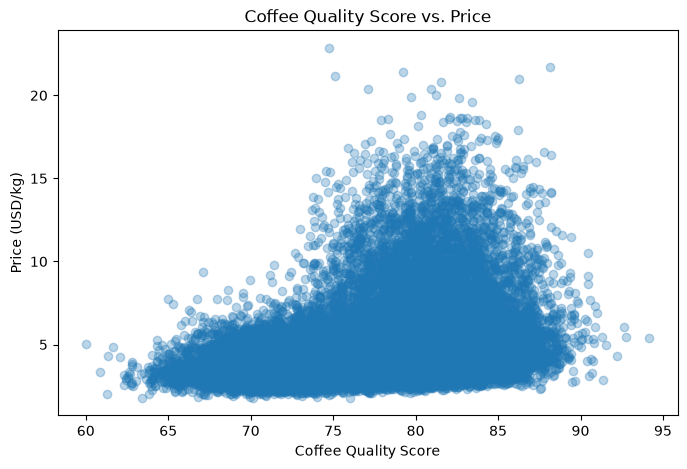

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    coffee_clean["coffee_quality_score"],
    coffee_clean["price_usd_per_kg"],
    alpha=0.3
)

plt.xlabel("Coffee Quality Score")
plt.ylabel("Price (USD/kg)")
plt.title("Coffee Quality Score vs. Price")
plt.show()

In [20]:
correlation = coffee_clean[
    ["coffee_quality_score", "price_usd_per_kg"]
].corr()

correlation

,coffee_quality_score,price_usd_per_kg
coffee_quality_score,1.000000,0.335958
price_usd_per_kg,0.335958,1.000000


Coffee quality and price show a moderate positive association (Pearson r ≈ 0.336). This indicates that higher-quality coffee tends to command higher prices, although quality alone does not explain most variation in price.

In [21]:
quality_by_origin = (
    coffee_clean
    .groupby("country_of_origin")["coffee_quality_score"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

quality_by_origin

,count,mean,median,std
country_of_origin,,,,
Kenya,2399,81.328429,81.41,3.153092
Colombia,5264,81.076989,81.08,3.175777
Ethiopia,3507,80.758808,80.80,3.095480
Honduras,2761,80.279388,80.35,3.244057
Brazil,11269,77.322105,77.91,4.460354
Indonesia,3452,73.850779,73.24,4.325754
Vietnam,6348,72.922569,72.78,3.491890


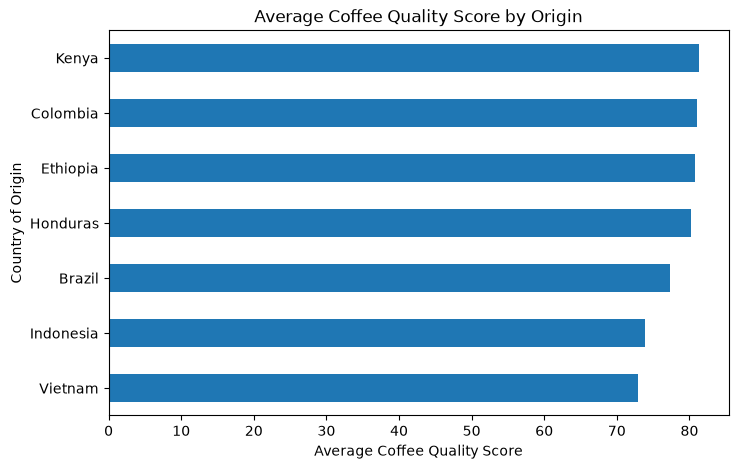

In [22]:
quality_by_origin["mean"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Average Coffee Quality Score")
plt.ylabel("Country of Origin")
plt.title("Average Coffee Quality Score by Origin")
plt.show()

In [23]:
price_by_origin = (
    coffee_clean
    .groupby("country_of_origin")["price_usd_per_kg"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

price_by_origin

,count,mean,median,std
country_of_origin,,,,
Kenya,2399,6.851855,5.90,2.915948
Ethiopia,3507,6.056963,5.23,2.594331
Colombia,5264,5.644286,4.86,2.449472
Honduras,2761,4.861956,4.14,2.131259
Brazil,11269,4.420778,3.89,1.830158
Indonesia,3452,4.180823,3.91,1.334509
Vietnam,6348,3.678245,3.50,0.998219


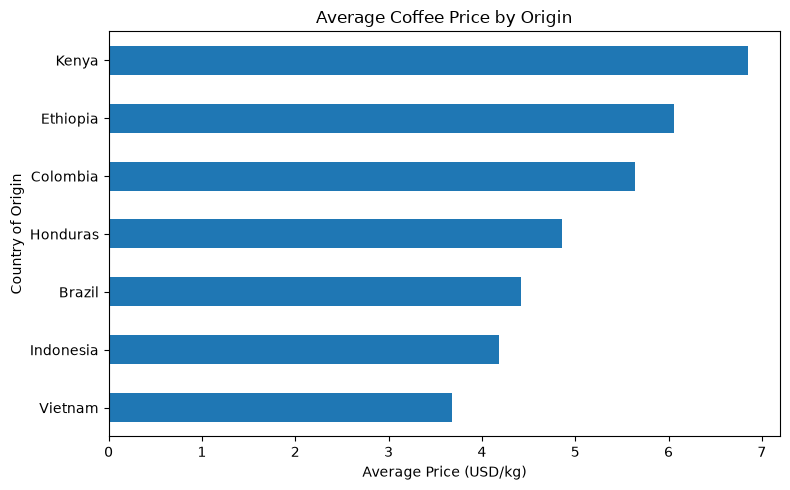

In [24]:
price_by_origin["mean"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Average Price (USD/kg)")
plt.ylabel("Country of Origin")
plt.title("Average Coffee Price by Origin")
plt.tight_layout()
plt.show()

### Interpretation

Quality and price rankings vary substantially by origin. Kenya, Colombia, and Ethiopia have among the highest average quality scores and prices, while Vietnam and Indonesia are lower on both measures. These differences are descriptive associations and should not be interpreted as evidence that origin itself causes higher quality or prices.

In [25]:
quality_by_processing = (
    coffee_clean
    .groupby("processing_method")["coffee_quality_score"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

quality_by_processing

,count,mean,median,std
processing_method,,,,
Anaerobic,702,79.157293,79.50,4.857580
Washed,17543,78.144370,78.90,4.950145
Honey,2731,77.649524,78.31,4.889122
Natural,14024,76.828359,77.39,4.768616


In [26]:
price_by_processing = (
    coffee_clean
    .groupby("processing_method")["price_usd_per_kg"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

price_by_processing

,count,mean,median,std
processing_method,,,,
Anaerobic,702,5.757179,5.03,2.573708
Honey,2731,5.049996,4.39,2.375481
Washed,17543,4.890907,4.26,2.240829
Natural,14024,4.619219,4.02,2.052918


### Interpretation

Anaerobic processing has the highest average quality score and price in the dataset, although it represents a relatively small number of lots. Washed coffee shows higher average quality than Natural coffee, while Honey processing has a higher average price than Washed coffee. This suggests that price differences are not explained by quality alone.

In [27]:
quality_by_certification = (
    coffee_clean
    .groupby("certification")["coffee_quality_score"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

quality_by_certification

,count,mean,median,std
certification,,,,
Rainforest Alliance,1601,77.845116,78.550,4.870470
Multiple,2751,77.735282,78.310,4.802092
Organic,3566,77.704425,78.320,4.882075
Not Recorded,21296,77.571272,78.230,4.943695
Fair Trade,5786,77.501777,78.055,4.897057


In [28]:
price_by_certification = (
    coffee_clean
    .groupby("certification")["price_usd_per_kg"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

price_by_certification

,count,mean,median,std
certification,,,,
Rainforest Alliance,1601,6.935028,5.880,3.224275
Multiple,2751,6.192188,5.380,2.817043
Organic,3566,5.742709,4.895,2.697735
Fair Trade,5786,4.582814,4.200,1.566551
Not Recorded,21296,4.380252,3.910,1.815979


Certification categories show relatively small differences in average quality, but substantially larger differences in average price. This suggests that market price is influenced by factors beyond measured quality alone. Because "Not Recorded" represents missing certification information, these results should be interpreted as descriptive associations rather than causal effects.

In [29]:
buyer_analysis = (
    coffee_clean
    .groupby("intended_buyer_segment")
    .agg(
        lots=("lot_id", "count"),
        avg_quality=("coffee_quality_score", "mean"),
        median_quality=("coffee_quality_score", "median"),
        avg_price=("price_usd_per_kg", "mean"),
        median_price=("price_usd_per_kg", "median")
    )
    .sort_values("avg_price", ascending=False)
)

buyer_analysis

,lots,avg_quality,median_quality,avg_price,median_price
intended_buyer_segment,,,,,
Specialty,3260,80.776982,80.765,9.969641,9.59
Premium,7987,78.581620,79.190,5.493811,5.32
Commodity,23753,76.832084,77.170,3.874631,3.74


### Interpretation

Specialty coffee has substantially higher average prices than Premium and Commodity coffee, while its average quality advantage is comparatively smaller. This suggests that market positioning and buyer segment may be associated with substantial differences in price beyond measured quality alone.

In [30]:
sensory_cols = [
    "acidity_score",
    "sweetness_score",
    "body_score",
    "aroma_score",
    "flavor_score"
]

sensory_correlation = (
    coffee_clean[sensory_cols + ["coffee_quality_score"]]
    .corr()["coffee_quality_score"]
    .drop("coffee_quality_score")
    .sort_values(ascending=False)
)

sensory_correlation


flavor_score       0.729724
acidity_score      0.699951
aroma_score        0.669587
sweetness_score    0.659742
body_score         0.065403
Name: coffee_quality_score, dtype: float64

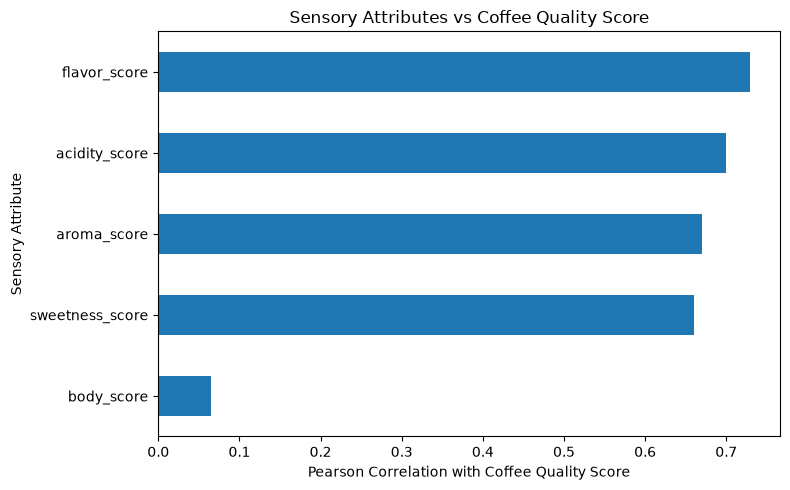

In [31]:
plt.figure(figsize=(8, 5))

sensory_correlation.sort_values().plot(
    kind="barh"
)

plt.xlabel("Pearson Correlation with Coffee Quality Score")
plt.ylabel("Sensory Attribute")
plt.title("Sensory Attributes vs Coffee Quality Score")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

### Interpretation

Flavor, acidity, aroma, and sweetness show strong positive associations with coffee quality scores, while body has a much weaker relationship. These results are descriptive because sensory attributes may themselves contribute to the construction of the overall quality score.

In [32]:
production_cols = [
    "farm_size_hectares",
    "tree_age_years",
    "altitude_mean_meters",
    "avg_temp_c",
    "avg_annual_rainfall_mm",
    "humidity_pct",
    "drying_duration_days",
    "storage_months",
    "bean_size_screen",
    "moisture_pct",
    "bean_density_g_ml",
    "defect_rate_pct"
]

production_correlation = (
    coffee_clean[production_cols + ["coffee_quality_score"]]
    .corr()["coffee_quality_score"]
    .drop("coffee_quality_score")
    .sort_values(ascending=False)
)

production_correlation

bean_density_g_ml         0.880094
altitude_mean_meters      0.681853
drying_duration_days      0.019523
bean_size_screen          0.016194
farm_size_hectares        0.000195
tree_age_years           -0.001630
storage_months           -0.028683
avg_annual_rainfall_mm   -0.135581
moisture_pct             -0.154539
defect_rate_pct          -0.197871
humidity_pct             -0.263327
avg_temp_c               -0.673655
Name: coffee_quality_score, dtype: float64

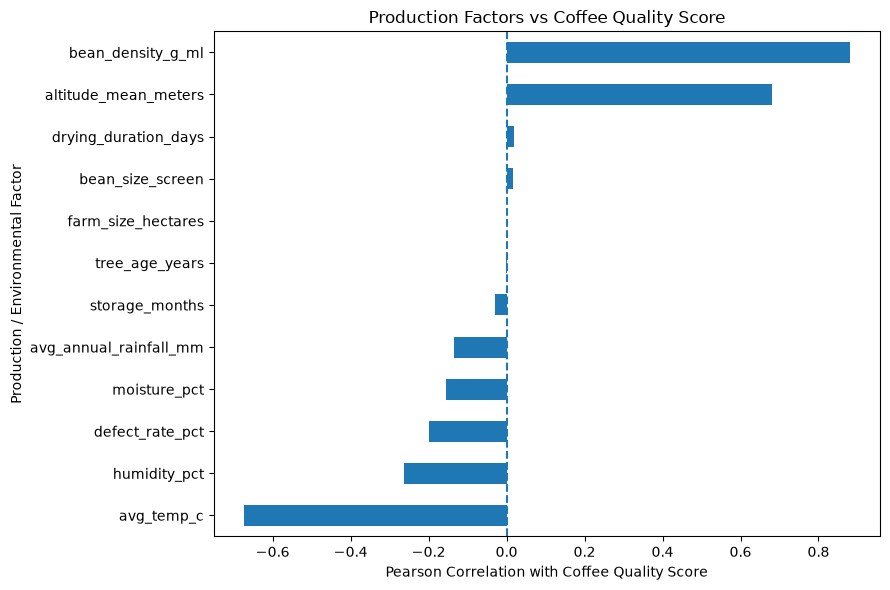

In [33]:
plt.figure(figsize=(9, 6))

production_correlation.sort_values().plot(
    kind="barh"
)

plt.xlabel("Pearson Correlation with Coffee Quality Score")
plt.ylabel("Production / Environmental Factor")
plt.title("Production Factors vs Coffee Quality Score")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

## 5. Production and Environmental Factors

Bean density and altitude show strong positive correlations with quality, while average temperature shows a strong negative correlation. Defect rate, humidity, and moisture show weaker negative relationships.

These are correlations rather than causal effects and may reflect relationships among environmental and production characteristics.

## 6. Regression Modeling

A multivariable OLS regression was used to examine which production and environmental characteristics were associated with coffee quality while controlling for the other variables in the model.

In [34]:
regression_vars = [
    "bean_density_g_ml",
    "altitude_mean_meters",
    "avg_temp_c",
    "humidity_pct",
    "defect_rate_pct",
    "moisture_pct",
    "avg_annual_rainfall_mm",
    "drying_duration_days",
    "storage_months",
    "bean_size_screen",
    "tree_age_years",
    "farm_size_hectares"
]

regression_data = coffee_clean[
    regression_vars + ["coffee_quality_score"]
].copy()

print("Regression dataset shape:", regression_data.shape)
print("\nMissing values:")
print(regression_data.isna().sum())

Regression dataset shape: (35000, 13)

Missing values:
bean_density_g_ml         0
altitude_mean_meters      0
avg_temp_c                0
humidity_pct              0
defect_rate_pct           0
moisture_pct              0
avg_annual_rainfall_mm    0
drying_duration_days      0
storage_months            0
bean_size_screen          0
tree_age_years            0
farm_size_hectares        0
coffee_quality_score      0
dtype: int64


In [35]:
X_vif = regression_data[regression_vars].copy()

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data.sort_values("VIF", ascending=False)

,feature,VIF
2,avg_temp_c,16.960880
1,altitude_mean_meters,16.310149
3,humidity_pct,5.780805
6,avg_annual_rainfall_mm,4.475050
0,bean_density_g_ml,3.253298
5,moisture_pct,2.115176
7,drying_duration_days,1.862674
9,bean_size_screen,1.179628
4,defect_rate_pct,1.160470
8,storage_months,1.156362


In [36]:
environment_correlation = coffee_clean[
    [
        "altitude_mean_meters",
        "avg_temp_c",
        "humidity_pct",
        "avg_annual_rainfall_mm"
    ]
].corr()

environment_correlation

,altitude_mean_meters,avg_temp_c,humidity_pct,avg_annual_rainfall_mm
altitude_mean_meters,1.000000,-0.937892,-0.195038,0.000332
avg_temp_c,-0.937892,1.000000,0.425159,0.219002
humidity_pct,-0.195038,0.425159,1.000000,0.862635
avg_annual_rainfall_mm,0.000332,0.219002,0.862635,1.000000


### Multicollinearity Assessment

Altitude and average temperature are strongly negatively correlated, while humidity and rainfall are strongly positively correlated. The initial VIF analysis also indicated elevated multicollinearity for temperature and altitude.

To improve model stability and interpretability, average temperature and rainfall were removed from the multivariable model while retaining altitude and humidity.

In [37]:
regression_vars_reduced = [
    "bean_density_g_ml",
    "altitude_mean_meters",
    "humidity_pct",
    "defect_rate_pct",
    "moisture_pct",
    "drying_duration_days",
    "storage_months",
    "bean_size_screen",
    "tree_age_years",
    "farm_size_hectares"
]

X = regression_data[regression_vars_reduced]
y = regression_data["coffee_quality_score"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     coffee_quality_score   R-squared:                       0.854
Model:                              OLS   Adj. R-squared:                  0.854
Method:                   Least Squares   F-statistic:                 2.052e+04
Date:                  Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                          17:26:34   Log-Likelihood:                -71688.
No. Observations:                 35000   AIC:                         1.434e+05
Df Residuals:                     34989   BIC:                         1.435e+05
Df Model:                            10                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [38]:
X_vif_reduced = regression_data[regression_vars_reduced].copy()

vif_reduced = pd.DataFrame({
    "feature": X_vif_reduced.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_reduced.values, i
        )
        for i in range(X_vif_reduced.shape[1])
    ]
})

vif_reduced.sort_values("VIF", ascending=False)

,feature,VIF
0,bean_density_g_ml,3.246060
1,altitude_mean_meters,2.975375
4,moisture_pct,2.114737
5,drying_duration_days,1.851193
2,humidity_pct,1.263676
7,bean_size_screen,1.179132
3,defect_rate_pct,1.158575
6,storage_months,1.156267
9,farm_size_hectares,1.011248
8,tree_age_years,1.011177


The reduced model has VIF values below 5 for all predictors, indicating no serious multicollinearity among the retained variables.

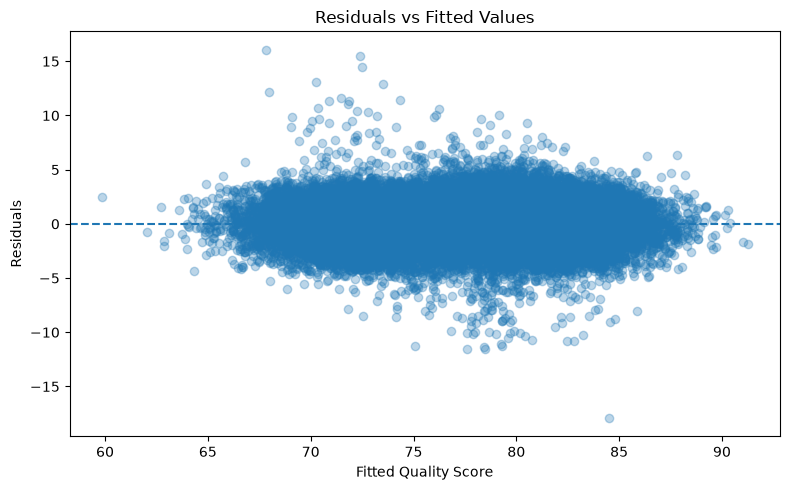

In [39]:
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(8, 5))

plt.scatter(
    fitted,
    residuals,
    alpha=0.3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Quality Score")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.tight_layout()
plt.show()

### Heteroscedasticity

The residual plot shows generally centered residuals but some variation in residual spread and several outliers.

The Breusch–Pagan test is statistically significant (p = 0.0031), indicating heteroscedasticity. Therefore, HC3 heteroscedasticity-robust standard errors are used for inference.

In [40]:

bp_test = het_breuschpagan(
    model.resid,
    model.model.exog
)

bp_results = pd.Series(
    bp_test,
    index=[
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ]
)

bp_results

LM Statistic    26.501213
LM p-value       0.003121
F Statistic      2.651296
F p-value        0.003116
dtype: float64

In [41]:
robust_model = model.get_robustcov_results(cov_type="HC3")

print(robust_model.summary())

                             OLS Regression Results                             
Dep. Variable:     coffee_quality_score   R-squared:                       0.854
Model:                              OLS   Adj. R-squared:                  0.854
Method:                   Least Squares   F-statistic:                 2.187e+04
Date:                  Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                          17:26:37   Log-Likelihood:                -71688.
No. Observations:                 35000   AIC:                         1.434e+05
Df Residuals:                     34989   BIC:                         1.435e+05
Df Model:                            10                                         
Covariance Type:                    HC3                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [42]:
predictions = model.predict(X)

mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.4401357610651162
RMSE: 1.8762988145204054


The model explains 85.4% of the variation in coffee quality scores (R² = 0.854). On the analysis dataset, the model has an MAE of 1.44 quality-score points and an RMSE of 1.88 points.

These are in-sample performance measures because predictions were generated from the same observations used to fit the model. They should therefore not be interpreted as out-of-sample predictive performance.

### Actual vs Predicted Quality

The predictions generally follow the observed quality scores closely, consistent with the model's relatively high R². Some observations show larger prediction errors, particularly around the middle and upper ranges of the quality scores.

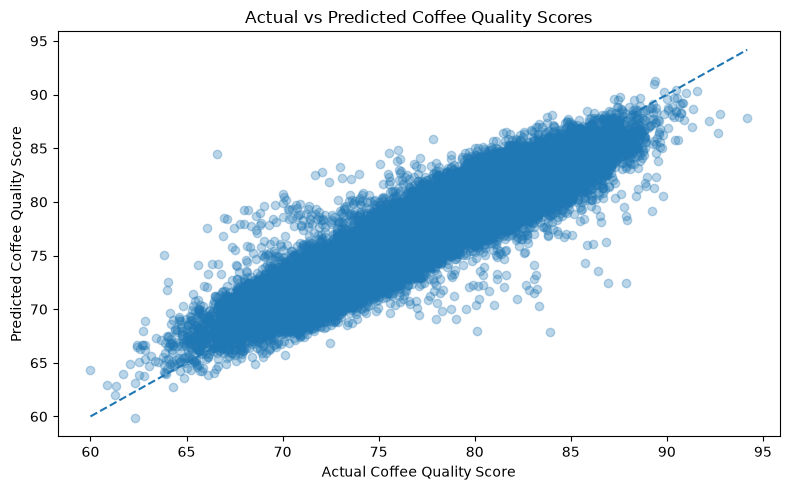

In [43]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y,
    predictions,
    alpha=0.3
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--"
)

plt.xlabel("Actual Coffee Quality Score")
plt.ylabel("Predicted Coffee Quality Score")
plt.title("Actual vs Predicted Coffee Quality Scores")

plt.tight_layout()
plt.show()

## 7. Value Opportunity Analysis

To identify potentially underpriced high-quality coffee, actual prices are compared with benchmark prices estimated from observable characteristics.

A negative price gap indicates that a coffee lot's observed price is below the model-based benchmark for similar lots. These results represent potential pricing opportunities rather than proof of mispricing.

In [44]:
price_benchmark_vars = [
    "coffee_quality_score",
    "country_of_origin",
    "processing_method",
    "certification",
    "intended_buyer_segment"
]

price_data = coffee_clean[
    price_benchmark_vars + ["price_usd_per_kg"]
].copy()

price_data.head()

,coffee_quality_score,country_of_origin,processing_method,certification,intended_buyer_segment,price_usd_per_kg
0,78.01,Vietnam,Natural,Not Recorded,Commodity,2.43
1,75.62,Honduras,Anaerobic,Not Recorded,Commodity,4.06
2,72.41,Vietnam,Washed,Not Recorded,Premium,4.26
3,75.67,Vietnam,Washed,Not Recorded,Commodity,3.60
4,73.77,Brazil,Honey,Not Recorded,Commodity,4.16


In [45]:
price_model = smf.ols(
    "price_usd_per_kg ~ coffee_quality_score + C(country_of_origin) + C(processing_method) + C(certification) + C(intended_buyer_segment)",
    data=price_data
).fit()

print(price_model.summary())

                            OLS Regression Results                            
Dep. Variable:       price_usd_per_kg   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.787
Method:                 Least Squares   F-statistic:                     8065.
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        17:26:39   Log-Likelihood:                -50140.
No. Observations:               35000   AIC:                         1.003e+05
Df Residuals:                   34983   BIC:                         1.005e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [46]:
price_data["expected_price_usd_per_kg"] = price_model.predict(price_data)

price_data["price_gap_usd_per_kg"] = (
    price_data["price_usd_per_kg"]
    - price_data["expected_price_usd_per_kg"]
)

price_data["price_gap_pct"] = (
    price_data["price_gap_usd_per_kg"]
    / price_data["expected_price_usd_per_kg"]
) * 100

price_data[
    [
        "price_usd_per_kg",
        "expected_price_usd_per_kg",
        "price_gap_usd_per_kg",
        "price_gap_pct"
    ]
].head(10)

,price_usd_per_kg,expected_price_usd_per_kg,price_gap_usd_per_kg,price_gap_pct
0,2.43,3.142958,-0.712958,-22.684301
1,4.06,4.332057,-0.272057,-6.280097
2,4.26,4.493947,-0.233947,-5.205817
3,3.60,3.126901,0.473099,15.129975
4,4.16,3.490596,0.669404,19.177368
5,3.37,3.380579,-0.010579,-0.312928
6,3.09,3.242810,-0.152810,-4.712272
7,2.88,4.635610,-1.755610,-37.872252
8,3.26,3.371452,-0.111452,-3.305746
9,4.41,5.622455,-1.212455,-21.564511


In [47]:
quality_threshold = coffee_clean["coffee_quality_score"].quantile(0.75)

print("High-quality threshold:", round(quality_threshold, 2))

High-quality threshold: 81.32


In [48]:
high_quality = price_data[
    price_data["coffee_quality_score"] >= quality_threshold
].copy()

print("High-quality lots:", len(high_quality))

High-quality lots: 8761


In [50]:
print("High-quality lots:", len(high_quality))
print(
    "Potentially underpriced:",
    (high_quality["price_gap_usd_per_kg"] < 0).sum()
)
print(
    "Percentage potentially underpriced:",
    round(
        (high_quality["price_gap_usd_per_kg"] < 0).mean() * 100,
        2
    ),
    "%"
)

High-quality lots: 8761
Potentially underpriced: 4536
Percentage potentially underpriced: 51.77 %


In [51]:
strong_opportunities = high_quality[
    high_quality["price_gap_pct"] <= -10
].copy()

print("Strong potential opportunities:", len(strong_opportunities))
print(
    "Percentage of high-quality lots:",
    round(len(strong_opportunities) / len(high_quality) * 100, 2),
    "%"
)

Strong potential opportunities: 2578
Percentage of high-quality lots: 29.43 %


In [57]:
potential_opportunities = high_quality.sort_values(
    "price_gap_usd_per_kg"
).copy()

potential_opportunities[
    [
        "coffee_quality_score",
        "country_of_origin",
        "processing_method",
        "certification",
        "intended_buyer_segment",
        "price_usd_per_kg",
        "expected_price_usd_per_kg",
        "price_gap_usd_per_kg",
        "price_gap_pct"
    ]
].head(10)

,coffee_quality_score,country_of_origin,processing_method,certification,intended_buyer_segment,price_usd_per_kg,expected_price_usd_per_kg,price_gap_usd_per_kg,price_gap_pct
14615,81.77,Honduras,Natural,Organic,Specialty,4.49,9.483166,-4.993166,-52.652945
30858,84.96,Ethiopia,Natural,Not Recorded,Specialty,5.32,10.250748,-4.930748,-48.101347
4314,81.56,Brazil,Natural,Organic,Specialty,4.71,9.378263,-4.668263,-49.777482
24737,82.24,Ethiopia,Natural,Rainforest Alliance,Specialty,6.70,11.219786,-4.519786,-40.284065
34735,82.68,Brazil,Natural,Organic,Specialty,4.98,9.381653,-4.401653,-46.917669
4841,82.65,Brazil,Natural,Rainforest Alliance,Specialty,5.49,9.808207,-4.318207,-44.026467
3915,83.49,Ethiopia,Natural,Multiple,Specialty,7.12,11.419446,-4.299446,-37.650213
33314,81.62,Brazil,Washed,Rainforest Alliance,Specialty,5.51,9.796114,-4.286114,-43.753208
15478,83.14,Indonesia,Natural,Multiple,Specialty,6.08,10.246093,-4.166093,-40.660307
12375,85.88,Colombia,Washed,Multiple,Specialty,6.87,10.979334,-4.109334,-37.427897


In [62]:
country_opportunity_rate = (
    high_quality
    .groupby("country_of_origin")
    .agg(
        high_quality_lots=("price_gap_pct", "size"),
        strong_opportunities=("price_gap_pct", lambda x: (x <= -10).sum())
    )
)

country_opportunity_rate["opportunity_rate_pct"] = (
    country_opportunity_rate["strong_opportunities"]
    / country_opportunity_rate["high_quality_lots"]
    * 100
)

country_opportunity_rate.sort_values(
    "opportunity_rate_pct",
    ascending=False
)

,high_quality_lots,strong_opportunities,opportunity_rate_pct
country_of_origin,,,
Kenya,1227,409,33.333333
Ethiopia,1534,478,31.160365
Indonesia,232,70,30.172414
Colombia,2464,743,30.154221
Vietnam,130,37,28.461538
Brazil,2141,573,26.763195
Honduras,1033,268,25.943853


# 8. Key Findings and Business Implications

### Key Findings

- Coffee quality and price showed a moderate positive association (Pearson r = 0.336), indicating that higher-quality coffee generally commands higher prices, but quality alone does not explain most price variation.

- Quality differed substantially by country of origin. Kenya, Colombia, and Ethiopia recorded the highest average quality scores, while Vietnam and Indonesia recorded lower average scores.

- Processing method was associated with both quality and price. Anaerobic processing recorded the highest average quality and price, although its relatively small sample size should be considered when interpreting the result.

- Certification showed relatively small differences in average quality but larger differences in price, suggesting that certification status may be more strongly associated with market value than with the overall quality score in this dataset.

- Specialty coffee recorded substantially higher prices than Premium and Commodity segments, while its quality advantage was comparatively smaller. This suggests that market positioning and buyer segment contribute significantly to price differences beyond measured quality.

- Sensory attributes, particularly flavor, acidity, aroma, and sweetness, showed strong positive associations with coffee quality. Body showed a much weaker relationship.

- In the multivariable quality model, bean density was the strongest positive predictor, while defect rate showed a strong negative association with quality. The reduced model explained approximately 85.4% of the variation in quality, although the observational nature of the data prevents causal interpretation.

- A model-based pricing benchmark explained approximately 78.7% of observed price variation using quality, origin, processing method, certification, and intended buyer segment.

- Using the top 25% of quality scores as the definition of high-quality coffee (quality score ≥ 81.32), 8,761 lots qualified as high-quality.

- Among these high-quality lots, 2,578 (29.43%) were priced at least 10% below their model-based benchmark, indicating a substantial group of potential pricing opportunities.

- Kenya and Ethiopia had the highest opportunity rates among high-quality lots, with 33.3% and 31.2% respectively meeting the ≥10% below-benchmark criterion.


### Business Implications

The analysis suggests that coffee value is influenced by a combination of quality, origin, processing, certification, and buyer segment rather than quality alone.

The pricing benchmark provides a practical framework for identifying high-quality lots whose observed prices are relatively low compared with similar coffees. These potential opportunities could be investigated further by coffee buyers, sourcing teams, and exporters when evaluating procurement and negotiation decisions.

The results also suggest that origin-specific and buyer-segment-specific pricing strategies may help identify where quality is not fully reflected in observed market prices.

However, the identified price gaps should be treated as screening signals rather than proof of mispricing, since the analysis is based on observational data and does not include every factor that may influence coffee prices.

### Limitations

- The dataset is observational, so the analysis identifies associations rather than causal relationships.
- "Not Recorded" certification values represent missing information and should not be interpreted as lack of certification.
- The pricing benchmark is based only on observable variables available in the dataset; unobserved commercial factors may also influence price.
- The price-gap analysis identifies potential opportunities rather than confirmed mispricing.
- Sensory variables may overlap conceptually with the overall quality score.
- Regression performance metrics reported for the quality model are based on the available dataset and should not be interpreted as out-of-sample predictive performance.